In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
from torch.utils.data import random_split
from torch.utils.data import Subset
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
from sklearn.model_selection import train_test_split



In [3]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

data_augmentation = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [4]:
data_dir = ".."
full_train = datasets.OxfordIIITPet(root=data_dir,split="trainval", transform=data_transform, download=False, target_types="category")
test = datasets.OxfordIIITPet(root=data_dir,split="test", transform=data_transform, download=False, target_types="category")


In [5]:
class_names = full_train.classes

def get_limited_dataloaders(train_dataset, fraction, batch_size=64):
    if fraction == 1.0:
            return DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    labels = [train_dataset.dataset._labels[i] for i in train_dataset.indices]
    selected, _ = train_test_split(train_dataset.indices, train_size=fraction, stratify=labels)
    limited_data = Subset(train_dataset.dataset, selected)
    return DataLoader(limited_data, batch_size=batch_size, shuffle=True, num_workers=0)


train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train, val = random_split(full_train, [train_size, val_size])

full_train_aug = datasets.OxfordIIITPet(root=data_dir,split="trainval", transform=data_augmentation, download=False, target_types="category")
train_aug = Subset(full_train_aug, train.indices)

val_loader = DataLoader(val, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test, batch_size=64, shuffle=False, num_workers=0)


dataloaders = []

fractions = [0.05, 0.1, 1.0]
for frac in fractions:
    train_loader = get_limited_dataloaders(train, frac)
    dataloaders.append({"train": train_loader, "val": val_loader, "test": test_loader})


In [6]:
dataloaders_aug = []

fractions = [0.05, 0.1, 1.0]
for frac in fractions:
    train_loader = get_limited_dataloaders(train_aug, frac)
    dataloaders_aug.append({"train": train_loader, "val": val_loader, "test": test_loader})


In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device}")

Using cuda


In [8]:
def evaluate_dataset(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device); labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
    total = len(dataloader.dataset)
    return running_loss / total, (running_corrects.double().item() / total)

In [9]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=25, l=1):
    since = time.time()

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch+1}/{num_epochs}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / len(dataloaders[phase].dataset)
                epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            train_loss_final, train_acc_final = evaluate_dataset(model, dataloaders['train'], criterion)
            val_loss_final, val_acc_final     = evaluate_dataset(model, dataloaders['val'],   criterion)

            train_loss_history.append(train_loss_final)
            train_acc_history.append(train_acc_final)
            val_loss_history.append(val_loss_final)
            val_acc_history.append(val_acc_final)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, map_location=device))
    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history

In [10]:
def set_finetune_l_layers(model, l):
    #freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    #always unfreeze classifier
    for param in model.fc.parameters():
        param.requires_grad = True

    #ResNet blocks in order from deep layers to shallow
    layers = [model.layer4, model.layer3, model.layer2, model.layer1]

    #unfreeze last l blocks
    for i in range(l):
        for param in layers[i].parameters():
            param.requires_grad = True

def describe_layers(l):
    names = ["layer4", "layer3", "layer2", "layer1"]
    return ["fc"] + names[:l]

def evaluate_on_test(model):
    model.eval()
    running_corrects = 0

    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(1)
            running_corrects += (preds == labels).sum().item()

    acc = running_corrects / len(dataloaders["test"].dataset)
    print(f"  Test accuracy: {acc:.4f}")
    return acc

In [11]:
def get_model():
    model = models.resnet34(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False
    model.fc = torch.nn.Linear(in_features=512, out_features=37)
    return model.to(device)

model = get_model()

criterion = torch.nn.CrossEntropyLoss()

optimizer_ft = optim.Adam(model.fc.parameters(), lr=0.001)


In [ ]:
results_base = []
results_data_aug = []
results_data_aug_l2 = []

for l in range(1, 5):
    for i, fraction in enumerate(fractions):
        print(f"Training with {int(fraction*100)}% of the training data")
        model = get_model()
        set_finetune_l_layers(model, l)
        optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
        scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
        dataloader = dataloaders[i]
        model, train_loss_history, val_loss_history, train_acc_history, val_acc_history = train_model(model, dataloader, criterion, optimizer_ft, scheduler, num_epochs=10)

        results_base.append((l, fraction, train_loss_history, val_loss_history, train_acc_history, val_acc_history))


for i, fraction in enumerate(fractions):
    print(f"Training with {int(fraction*100)}% of the training data and data augmentation")
    model = get_model()
    set_finetune_l_layers(model, 4)
    optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=0)
    scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
    dataloader = dataloaders_aug[i]
    model, train_loss_history, val_loss_history, train_acc_history, val_acc_history = train_model(model, dataloader, criterion, optimizer_ft, scheduler, num_epochs=10)

    results_data_aug.append((4, fraction, train_loss_history, val_loss_history, train_acc_history, val_acc_history))

for i, fraction in enumerate(fractions):
    print(f"Training with {int(fraction*100)}% of the training data and data augmentation")
    model = get_model()
    set_finetune_l_layers(model, 4)
    optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=1e-3)
    scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
    dataloader = dataloaders_aug[i]
    model, train_loss_history, val_loss_history, train_acc_history, val_acc_history = train_model(model, dataloader, criterion, optimizer_ft, scheduler, num_epochs=10)

    results_data_aug_l2.append((4, fraction, train_loss_history, val_loss_history, train_acc_history, val_acc_history))
    


Training with 5% of the training data
Epoch 1/10
----------
train Loss: 3.2694 Acc: 0.1633
val Loss: 1.9460 Acc: 0.4851

Epoch 2/10
----------
train Loss: 0.5355 Acc: 0.9796
val Loss: 2.4746 Acc: 0.4307

Epoch 3/10
----------
train Loss: 0.1648 Acc: 0.9932
val Loss: 1.7744 Acc: 0.5190

Epoch 4/10
----------
train Loss: 0.0632 Acc: 1.0000
val Loss: 1.5885 Acc: 0.5421

Epoch 5/10
----------
train Loss: 0.0313 Acc: 1.0000
val Loss: 1.5991 Acc: 0.5611

Epoch 6/10
----------
train Loss: 0.0207 Acc: 1.0000
val Loss: 1.6735 Acc: 0.5598

Epoch 7/10
----------
train Loss: 0.0125 Acc: 1.0000
val Loss: 1.6753 Acc: 0.5503

Epoch 8/10
----------
train Loss: 0.0083 Acc: 1.0000
val Loss: 1.6185 Acc: 0.5679

Epoch 9/10
----------
train Loss: 0.0093 Acc: 1.0000
val Loss: 1.5749 Acc: 0.5829

Epoch 10/10
----------
train Loss: 0.0099 Acc: 1.0000
val Loss: 1.5694 Acc: 0.5829

Training complete in 3m 14s
Best val Acc: 0.582880


C:\Users\samyz\AppData\Local\Temp\ipykernel_24672\377575469.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_params_path, map

Training with 10% of the training data
Epoch 1/10
----------
train Loss: 2.5915 Acc: 0.3299
val Loss: 1.5332 Acc: 0.5258

Epoch 2/10
----------
train Loss: 0.4507 Acc: 0.9354
val Loss: 1.2822 Acc: 0.6549

Epoch 3/10
----------
train Loss: 0.1339 Acc: 0.9796
val Loss: 1.4280 Acc: 0.6033

Epoch 4/10
----------
train Loss: 0.0426 Acc: 1.0000
val Loss: 1.2848 Acc: 0.6467

Epoch 5/10
----------
train Loss: 0.0152 Acc: 1.0000
val Loss: 1.0989 Acc: 0.6807

Epoch 6/10
----------
train Loss: 0.0112 Acc: 1.0000
val Loss: 1.0294 Acc: 0.7120

Epoch 7/10
----------
train Loss: 0.0063 Acc: 1.0000
val Loss: 0.9973 Acc: 0.7351

Epoch 8/10
----------
train Loss: 0.0053 Acc: 1.0000
val Loss: 0.9649 Acc: 0.7337

Epoch 9/10
----------
train Loss: 0.0048 Acc: 1.0000
val Loss: 0.9503 Acc: 0.7378

Epoch 10/10
----------
train Loss: 0.0040 Acc: 1.0000
val Loss: 0.9493 Acc: 0.7418

Training complete in 3m 40s
Best val Acc: 0.741848
Training with 100% of the training data
Epoch 1/10
----------
train Loss: 0.931

In [ ]:
# # Extract best validation accuracy for each (l, fraction) combination
# import pandas as pd

# l_unique = sorted(set(r[0] for r in results_l2))
# fractions_unique_l = sorted(set(r[1] for r in results_l2))

# # Build a matrix: best val acc for each (l, fraction)
# best_acc_matrix = {}
# for l in l_unique:
#     best_acc_matrix[l] = {}
#     for frac in fractions_unique_l:
#         run = next((r for r in results_l2 if r[0] == l and r[1] == frac), None)
#         if run:
#             best_acc_matrix[l][frac] = max(run[5])  # max validation accuracy
#         else:
#             best_acc_matrix[l][frac] = 0

# # Create DataFrame for heatmap
# df_heatmap = pd.DataFrame(best_acc_matrix).T
# df_heatmap.columns = [f'{int(f*100)}%' for f in df_heatmap.columns]
# df_heatmap.index = [f'l={l}' for l in df_heatmap.index]

# print("Best validation accuracy by unfrozen layers and data fraction:")
# print(df_heatmap)

Best validation accuracy by unfrozen layers and data fraction:
           5%       10%      100%
l=1  0.656250  0.722826  0.899457
l=2  0.320652  0.551630  0.853261
l=3  0.342391  0.533967  0.834239
l=4  0.347826  0.485054  0.813859


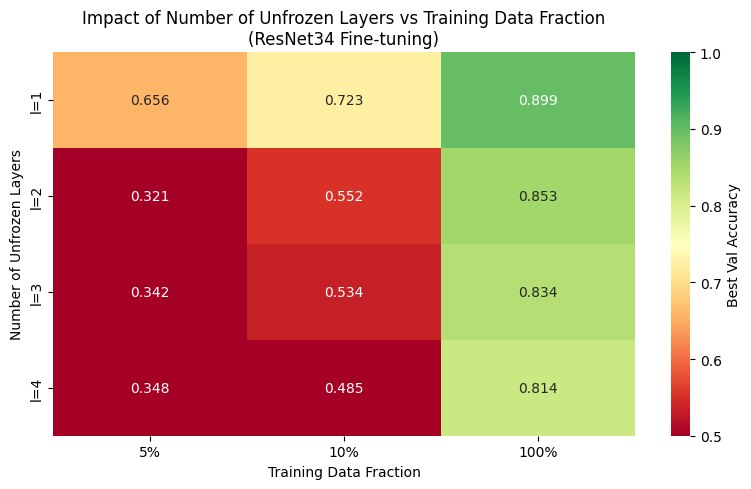


Key insights:
- Each cell shows best validation accuracy across 10 epochs
- Compare performance across l values and data fractions only


In [ ]:
# # Heatmap: l vs fractions - Best val accuracy
# import seaborn as sns

# fig, ax = plt.subplots(figsize=(8, 5))
# sns.heatmap(df_heatmap, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0, 
#             cbar_kws={'label': 'Best Val Accuracy'}, ax=ax)
# ax.set_title('Impact of Number of Unfrozen Layers vs Training Data Fraction\n(ResNet34 Fine-tuning)')
# ax.set_xlabel('Training Data Fraction')
# ax.set_ylabel('Number of Unfrozen Layers')
# plt.tight_layout()
# plt.savefig('../results_limited_data/l_layers_heatmap.png', dpi=150)
# plt.show()

# print("\nKey insights:")
# print("- Each cell shows best validation accuracy across 10 epochs")
# print("- Compare performance across l values and data fractions only")

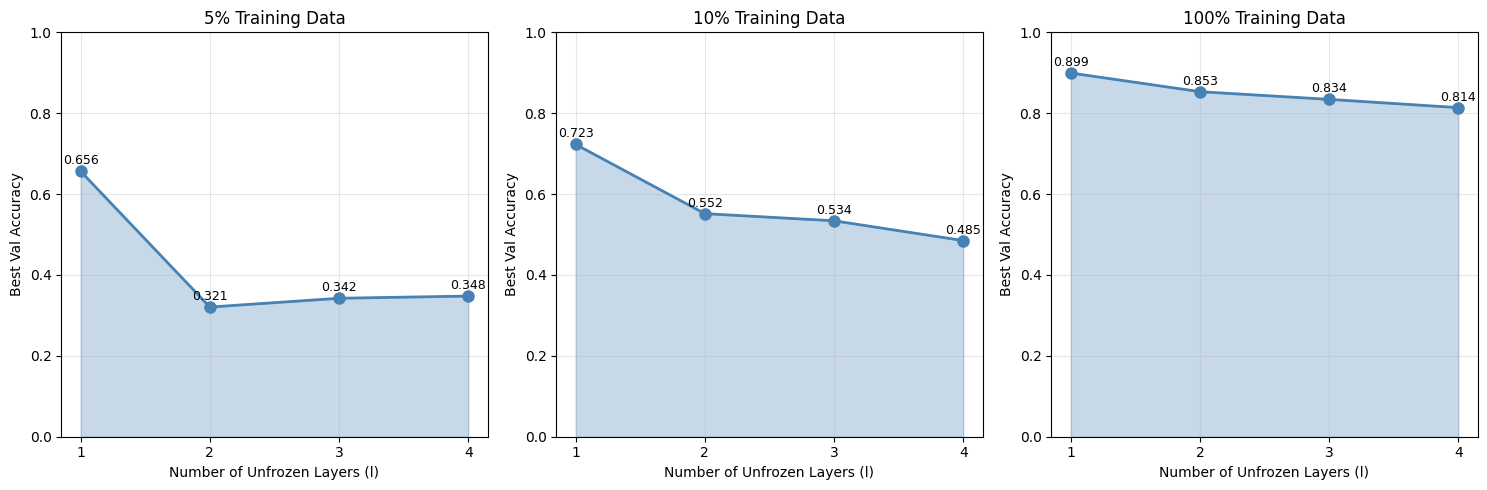

Effect of unfreezing more layers:
- Increasing l means training more layers
- Helps more when data is very limited (small fractions)
- May overfit when l is too large with limited data


In [ ]:
# # Line plot: How does performance change as we unfreeze more layers?
# fig, axes = plt.subplots(1, len(fractions_unique_l), figsize=(5*len(fractions_unique_l), 5))
# if len(fractions_unique_l) == 1:
#     axes = [axes]

# for ax, frac in zip(axes, fractions_unique_l):
#     best_accs_per_l = []
#     for l in l_unique:
#         run = next((r for r in results_l2 if r[0] == l and r[1] == frac), None)
#         if run:
#             best_accs_per_l.append(max(run[5]))
#         else:
#             best_accs_per_l.append(0)
    
#     ax.plot(l_unique, best_accs_per_l, marker='o', linewidth=2, markersize=8, color='steelblue')
#     ax.fill_between(l_unique, best_accs_per_l, alpha=0.3, color='steelblue')
#     ax.set_title(f'{int(frac*100)}% Training Data')
#     ax.set_xlabel('Number of Unfrozen Layers (l)')
#     ax.set_ylabel('Best Val Accuracy')
#     ax.set_xticks(l_unique)
#     ax.grid(True, alpha=0.3)
#     ax.set_ylim([0, 1.0])
    
#     # Annotate points
#     for l, acc in zip(l_unique, best_accs_per_l):
#         ax.annotate(f'{acc:.3f}', xy=(l, acc), xytext=(0, 5), 
#                    textcoords='offset points', ha='center', fontsize=9)

# plt.tight_layout()
# plt.savefig('../results_limited_data/l_effect_per_fraction.png', dpi=150)
# plt.show()

# print("Effect of unfreezing more layers:")
# print("- Increasing l means training more layers")
# print("- Helps more when data is very limited (small fractions)")
# print("- May overfit when l is too large with limited data")

In [ ]:
# # Summary table: Optimal l for each fraction
# summary_data = []
# for frac in fractions_unique_l:
#     best_l = None
#     best_acc = -1
    
#     for l in l_unique:
#         run = next((r for r in results_l2 if r[0] == l and r[1] == frac), None)
#         if run:
#             max_acc = max(run[5])
#             if max_acc > best_acc:
#                 best_acc = max_acc
#                 best_l = l
    
#     summary_data.append({
#         'Data Fraction': f'{int(frac*100)}%',
#         'Optimal l': best_l,
#         'Best Val Acc': f'{best_acc:.4f}',
#         'Trainable Params': ['fc'] + ['layer4', 'layer3', 'layer2', 'layer1'][:best_l] if best_l else 'N/A'
#     })

# df_summary = pd.DataFrame(summary_data)
# print("\n" + "="*70)
# print("SUMMARY: Optimal Strategy per Data Fraction")
# print("="*70)
# print(df_summary.to_string(index=False))
# print("="*70)

# print("\nInterpretation:")
# print("- FC = Fully Connected layer (always trained)")
# print("- layer4, layer3, layer2, layer1 = ResNet blocks from deep to shallow")
# print("- More layers can help on small fractions, but the best l can change with data size")


SUMMARY: Optimal Strategy per Data Fraction
Data Fraction  Optimal l Best Val Acc Trainable Params
           5%          1       0.6562     [fc, layer4]
          10%          1       0.7228     [fc, layer4]
         100%          1       0.8995     [fc, layer4]

Interpretation:
- FC = Fully Connected layer (always trained)
- layer4, layer3, layer2, layer1 = ResNet blocks from deep to shallow
- More layers can help on small fractions, but the best l can change with data size


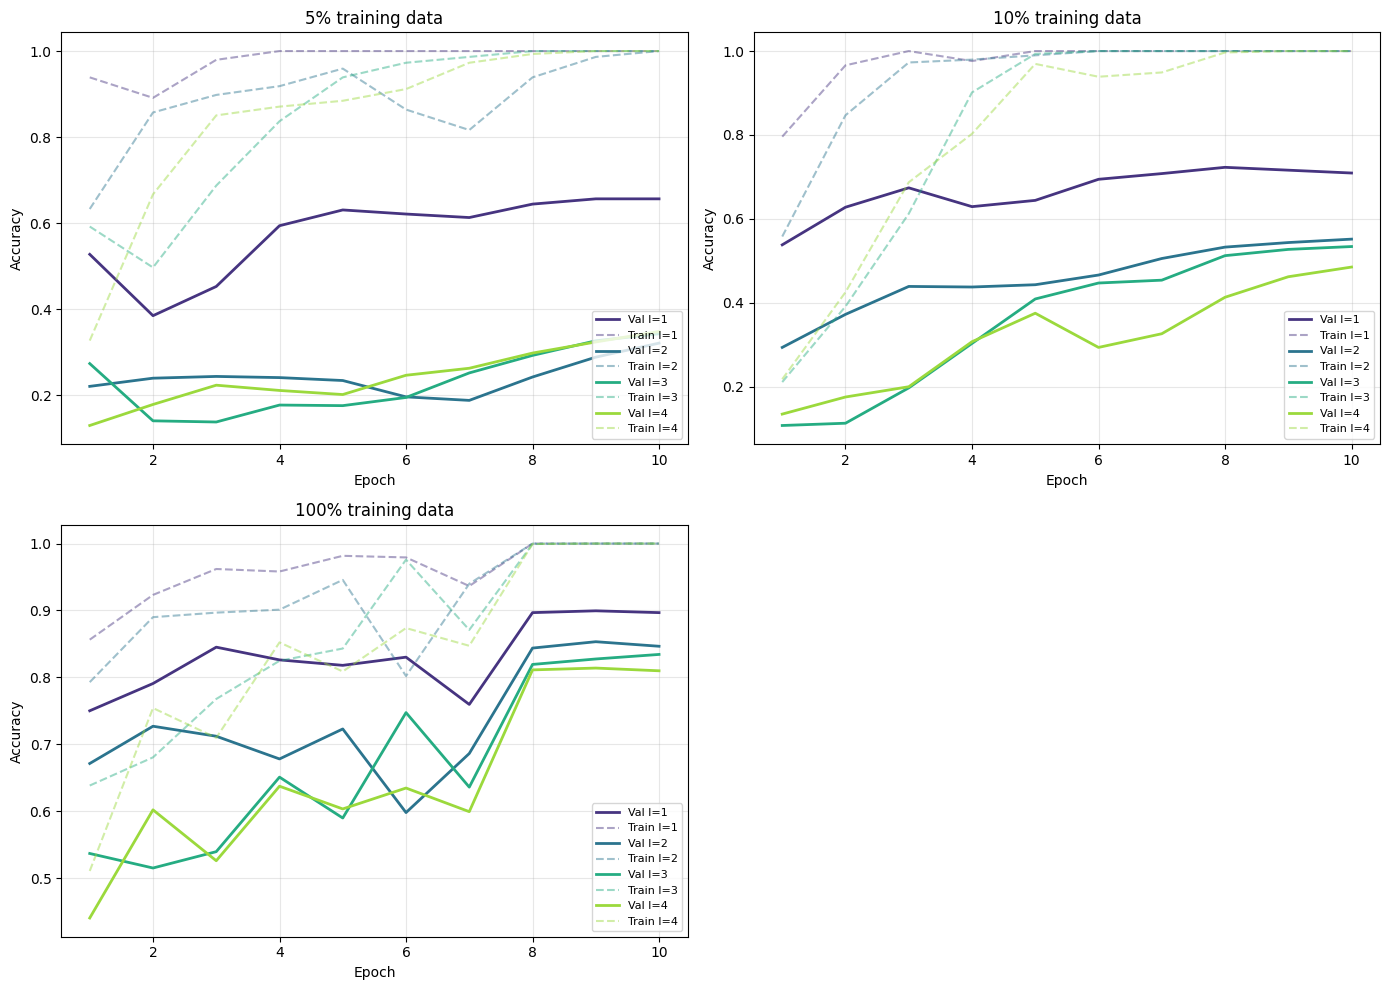

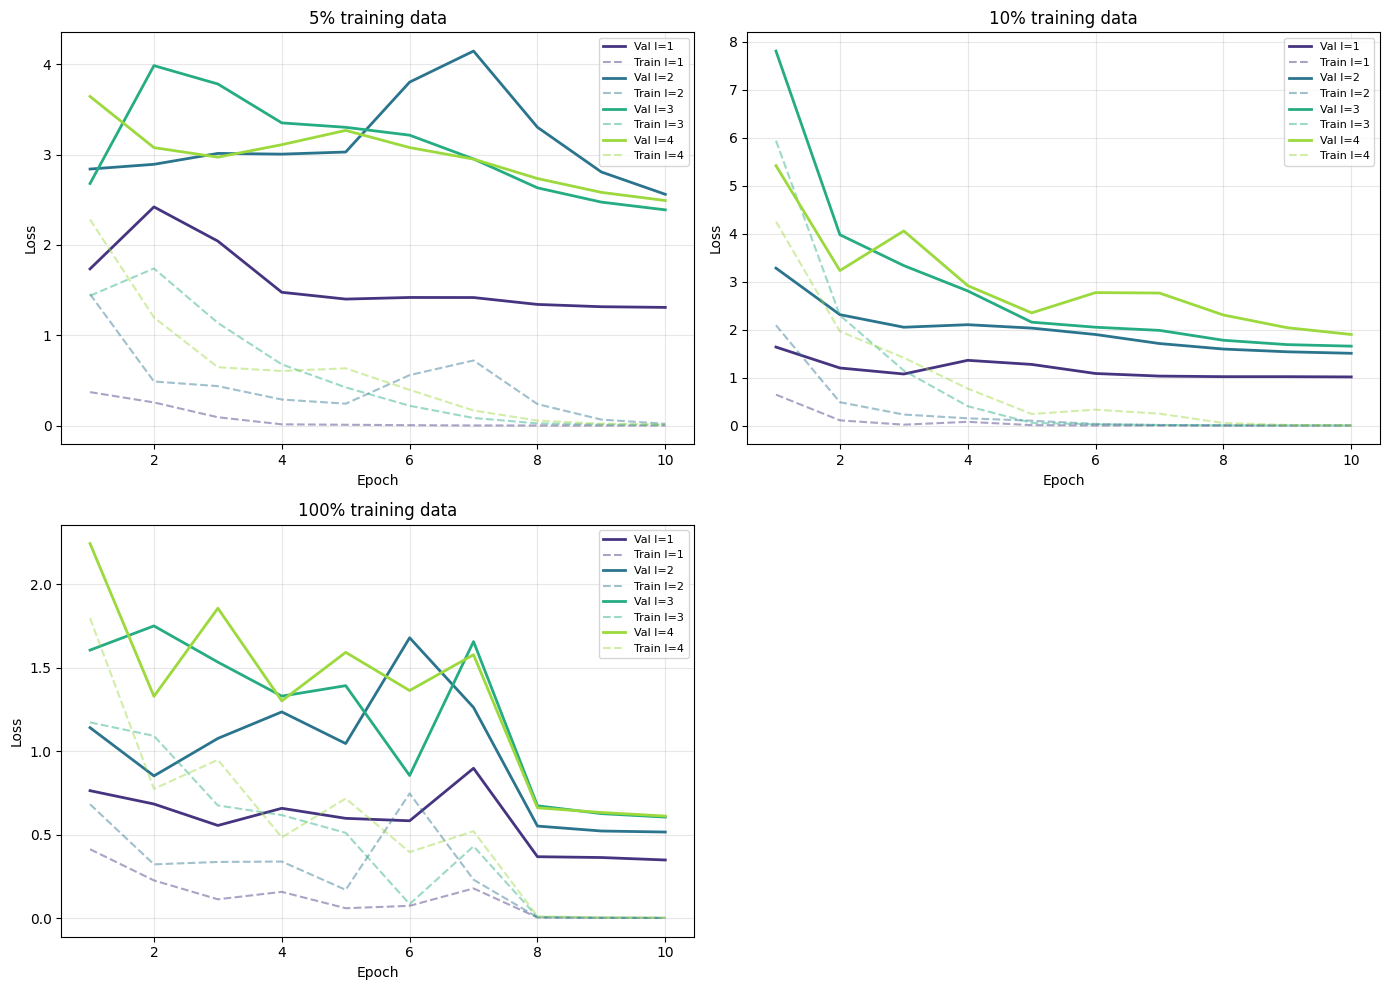

In [ ]:
# # Train/val curves per fraction, with one curve per l
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# axes = axes.flatten()

# colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(l_unique)))

# for ax, frac in zip(axes, fractions_unique_l):
#     for color, l in zip(colors, l_unique):
#         run = next((r for r in results_l2 if r[0] == l and r[1] == frac), None)
#         if run is None:
#             continue

#         _, _, train_loss, val_loss, train_acc, val_acc = run
#         epochs = range(1, len(val_acc) + 1)
#         label = f'l={l}'

#         line, = ax.plot(epochs, val_acc, linestyle='-', linewidth=2, color=color, label=f'Val {label}')
#         ax.plot(epochs, train_acc, linestyle='--', alpha=0.45, color=line.get_color(), label=f'Train {label}')

#     ax.set_title(f'{int(frac*100)}% training data')
#     ax.set_xlabel('Epoch')
#     ax.set_ylabel('Accuracy')
#     ax.grid(True, alpha=0.3)
#     ax.legend(fontsize=8, loc='lower right')

# for ax in axes[len(fractions_unique_l):]:
#     ax.axis('off')

# plt.tight_layout()
# plt.savefig('../results_limited_data/l_layers_accuracy_per_fraction.png', dpi=150)
# plt.show()

# # Train/val loss per fraction, with one curve per l
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# axes = axes.flatten()

# for ax, frac in zip(axes, fractions_unique_l):
#     for color, l in zip(colors, l_unique):
#         run = next((r for r in results_l2 if r[0] == l and r[1] == frac), None)
#         if run is None:
#             continue

#         _, _, train_loss, val_loss, train_acc, val_acc = run
#         epochs = range(1, len(val_loss) + 1)
#         label = f'l={l}'

#         line, = ax.plot(epochs, val_loss, linestyle='-', linewidth=2, color=color, label=f'Val {label}')
#         ax.plot(epochs, train_loss, linestyle='--', alpha=0.45, color=line.get_color(), label=f'Train {label}')

#     ax.set_title(f'{int(frac*100)}% training data')
#     ax.set_xlabel('Epoch')
#     ax.set_ylabel('Loss')
#     ax.grid(True, alpha=0.3)
#     ax.legend(fontsize=8, loc='upper right')

# for ax in axes[len(fractions_unique_l):]:
#     ax.axis('off')

# plt.tight_layout()
# plt.savefig('../results_limited_data/l_layers_loss_per_fraction.png', dpi=150)
# plt.show()